# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [ ]:
!pwd
!cd /content/
!git clone https://github.com/evgenkot/2025-Raschupkin-TimeSeriesCourse.git || echo present
!cd /content/2025-Raschupkin-TimeSeriesCourse
!git pull
!cd /content/2025-Raschupkin-TimeSeriesCourse/practice/06\ Chains

/content
fatal: destination path '2025-Raschupkin-TimeSeriesCourse' already exists and is not an empty directory.
present
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
import os

practice_dir_path = '/content/2025-Raschupkin-TimeSeriesCourse/practice/06 Chains'
os.chdir(practice_dir_path)

## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

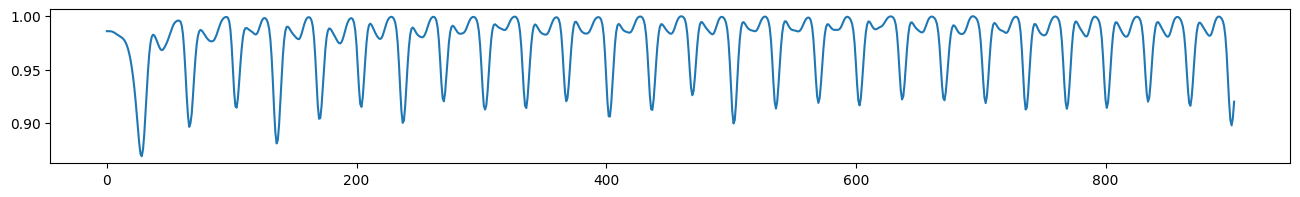

In [ ]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

In [ ]:
m = 50
mp = stumpy.stump(ts, m=m)
mp

mparray([[2.7408223578420863, 109, -1, 109],
         [2.6745163377709207, 110, -1, 110],
         [2.639759265328178, 111, -1, 111],
         ...,
         [0.695465642823677, 688, 688, -1],
         [0.8527226316083273, 689, 689, -1],
         [0.8139831346970323, 256, 256, -1]], dtype=object)

In [ ]:
all_chain_set, chain = stumpy.allc(mp[:, 2], mp[:, 3])
chain

array([ 16,  55, 124, 490, 524, 591])

Цепочка состоит из 6 звеньев

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

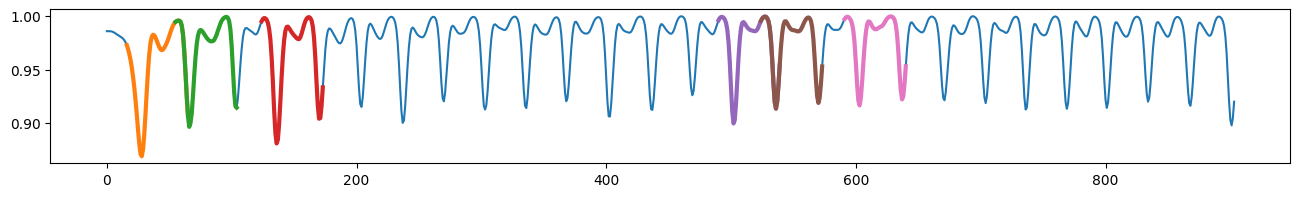

In [ ]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)
for i in range(chain.shape[0]):
    y = ts[chain[i]:chain[i]+m]
    x = range(chain[i], chain[i]+m)
    plt.plot(x, y, linewidth=3)

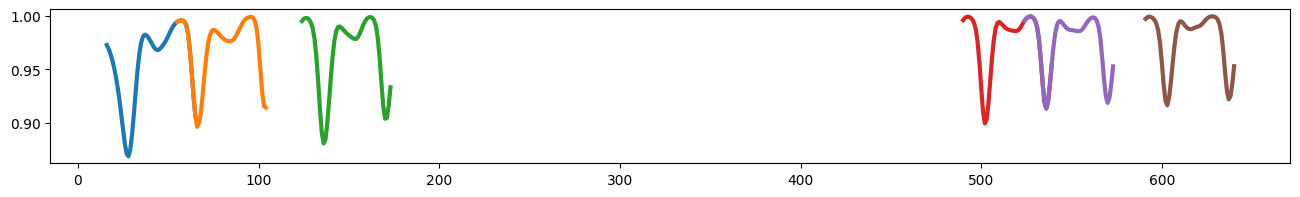

In [ ]:
fig, ax = plt.subplots(figsize=(16, 2))
for i in range(chain.shape[0]):
    y = ts[chain[i]:chain[i]+m]
    x = range(chain[i], chain[i]+m)
    plt.plot(x, y, linewidth=3)

Звенья имеют схожую форму, но отличаются по значению амплитуды

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [ ]:
i1, i2 = chain[-2:]
seg1 = ts[i1:i1+m]
seg2 = ts[i2:i2+m]

pred = seg2 + (seg2 - seg1)
real = ts[i2:i2+m]

accuracy = mean_squared_error(real, pred)
print(f"MSE: {accuracy}%")


MSE: 9.356913434730027e-06%


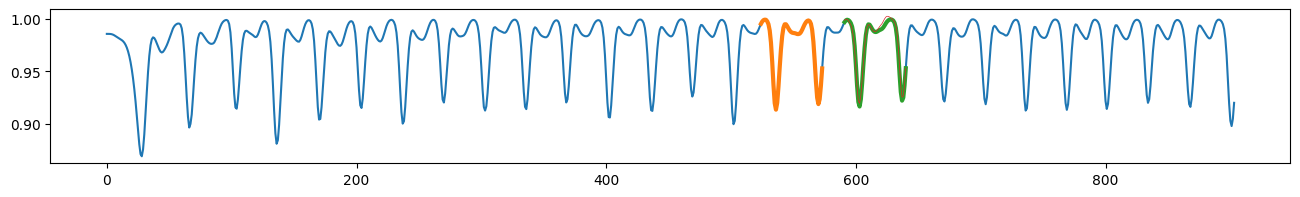

In [ ]:
fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)

for i in [-2, -1]:
    plt.plot(range(chain[i], chain[i] + m),
             ts[chain[i]:chain[i]+m], linewidth=3)

ax.plot(range(i2, i2 + m), pred, label="Predicted", linewidth=0.5)

Предсказанное значение накладывается на реальное.